# VGSOT Simulation – Updated API Guide

This notebook focuses on the **real parameter entry points** used by the project:

1. **High-level case APIs** accept a `Config` object.
2. **Default values live in `configs.py` dataclasses**.
3. Users can either:
   - run with the default config,
   - inspect the default values,
   - override selected fields,
   - or drop down to low-level APIs for full control.

> Recommended workflow: start from a case API + default `Config`, then customize only the fields you need.

## 0. Common imports

In [16]:
from pathlib import Path
from pprint import pprint
from dataclasses import fields, is_dataclass

import matplotlib.pyplot as plt
import numpy as np

from vgsot_sim import (
    config_to_params,
    save_single_plot,
    save_three_panel_plot,
    save_two_panel_plot,
    ensure_result_dir,

    TerminalVoltageControlConfig,
    SotOnlyConstantCurrentConfig,
    SotSwitchingNoVcmaConfig,
    SerSotNoVcmaThermalConfig,
    VcmaAssistedSwitchingIsotSweepConfig,
    VcmaAssistedSwitchingVmtjSweepConfig,
    OptimizedVgsotSwitchingConfig,
    SerOptimizedVgsotConfig,

    terminal_voltage_control,
    sot_only_constant_current,
    sot_switching_no_vcma,
    vcma_assisted_switching_isot_sweep,
    vcma_assisted_switching_vmtj_sweep,
    optimized_vgsot_switching,
    ser_sot_no_vcma_thermal,
    ser_optimized_vgsot,

    run_piecewise_direct_excitation,
    run_two_pulse_optimized,
)

OUT_DIR = ensure_result_dir("result_notebook")
print("Output directory:", OUT_DIR)

Output directory: result_notebook


## 1. How to expose default values from a Config

Every high-level case API uses a dataclass-style config.  
The easiest ways to inspect defaults are:

- print the config object,
- convert it to a dictionary with `config_to_params(...)`,
- or iterate over dataclass fields.

In [17]:
def show_config_defaults(cfg):
    print(cfg)
    print("\nAs dict:")
    pprint(config_to_params(cfg))

def show_config_fields(cfg_cls):
    print(cfg_cls.__name__)
    for f in fields(cfg_cls):
        print(f"  {f.name} = {f.default}")

cfg = SerSotNoVcmaThermalConfig()
show_config_defaults(cfg)

SerSotNoVcmaThermalConfig(i_sot_list=(-0.0001, -9.8e-05, -9.6e-05, -9.4e-05, -9.2e-05, -9e-05), trials=1000, sim_start_step=1, sim_mid1_step=2000, sim_end_step=5000, pap=1, non=1, v_mtj=0.0, vnv=0, r_sot_fl_dl=0.0, target_mz=-1.0, failure_tol=0.1)

As dict:
{'failure_tol': 0.1,
 'i_sot_list': (-0.0001, -9.8e-05, -9.6e-05, -9.4e-05, -9.2e-05, -9e-05),
 'non': 1,
 'pap': 1,
 'r_sot_fl_dl': 0.0,
 'sim_end_step': 5000,
 'sim_mid1_step': 2000,
 'sim_start_step': 1,
 'target_mz': -1.0,
 'trials': 1000,
 'v_mtj': 0.0,
 'vnv': 0}


You can also inspect just the field list:

In [18]:
show_config_fields(OptimizedVgsotSwitchingConfig)

OptimizedVgsotSwitchingConfig
  v_mtj_1 = 1.4937
  v_mtj_2 = -1.0
  i_sot = None
  t_pairs_s = ((2.5e-08, 0.0), (1.4e-09, 1.6e-09), (1.8e-09, 1.2e-09), (2.2e-09, 8e-10))
  sim_total_time_s = 2.5e-08
  pap = 1
  non = 1
  vnv = 1
  r_sot_fl_dl = 0.0
  tick_spacing_s = 5e-09


## 2. Default config vs custom config

### 2.1 Run with default config

In [19]:
res_default = sot_only_constant_current()
print(type(res_default).__name__)
print("time points:", res_default.time_s.shape)

direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 27645.14it/s]

SimResult
time points: (5001,)


### 2.2 Override only the fields you care about

The rest stay at their defaults.

In [20]:
cfg_custom = SotOnlyConstantCurrentConfig(
    i_sot_stage1=-105e-6,
    sim_mid1_step=1800,
    sim_end_step=4500,
    pap=1,
)

print(cfg_custom)
res_custom = sot_only_constant_current(cfg_custom)
print("custom result points:", res_custom.time_s.shape)

SotOnlyConstantCurrentConfig(sim_start_step=1, sim_mid1_step=1800, sim_end_step=4500, pap=1, i_sot_stage1=-0.000105, i_sot_stage2=0.0, v_mtj_stage1=0.0, v_mtj_stage2=0.0, vnv=1, non=1, r_sot_fl_dl=0.83, tick_spacing_s=5e-10)


direct_excitation: 100%|████████████████████████████████████████████████████████| 4500/4500 [00:00<00:00, 26383.95it/s]

custom result points: (4501,)


## 3. Recommended API layers

### High-level APIs
Use these for most experiments:

- `terminal_voltage_control(cfg)`
- `sot_only_constant_current(cfg)`
- `sot_switching_no_vcma(cfg)`
- `vcma_assisted_switching_isot_sweep(cfg)`
- `vcma_assisted_switching_vmtj_sweep(cfg)`
- `optimized_vgsot_switching(cfg)`
- `ser_sot_no_vcma_thermal(cfg)`
- `ser_optimized_vgsot(cfg)`

### Low-level APIs
Use these only when you want to manually define pulse timing and excitation:

- `run_piecewise_direct_excitation(...)`
- `run_two_pulse_optimized(...)`

## 4. Example: baseline SOT-only switching

This is the simplest pattern users should copy:

1. instantiate a config,
2. inspect it,
3. modify selected fields,
4. run the case.

Default baseline config:
{'i_sot_stage1': -9.5e-05,
 'i_sot_stage2': 0.0,
 'non': 1,
 'pap': 1,
 'r_sot_fl_dl': 0.83,
 'sim_end_step': 5000,
 'sim_mid1_step': 2000,
 'sim_start_step': 1,
 'tick_spacing_s': 5e-10,
 'v_mtj_stage1': 0.0,
 'v_mtj_stage2': 0.0,
 'vnv': 1}


direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 32213.48it/s]


Saved: result_notebook\sot_only_constant_current.png


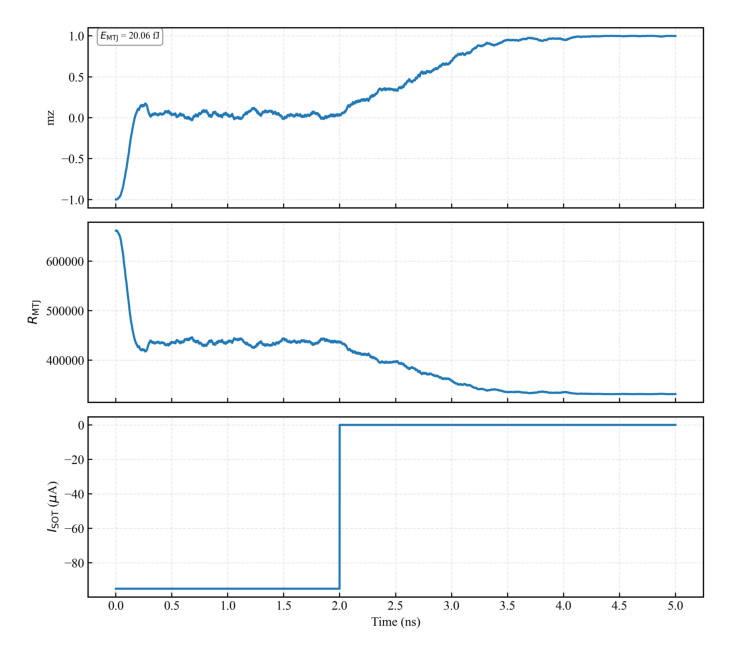

In [21]:
cfg = SotOnlyConstantCurrentConfig()
print("Default baseline config:")
pprint(config_to_params(cfg))

res = sot_only_constant_current(cfg)
baseline_path = OUT_DIR / "sot_only_constant_current.png"

save_three_panel_plot(
    baseline_path,
    res.time_s,
    {"mz": res.mz},
    {r"$R_{\mathrm{MTJ}}$": res.r_mtj},
    {r"$I_{\mathrm{SOT}}$": res.i_sot * 1e6},
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=r"$I_{\mathrm{SOT}}$ ($\mu$A)",
    tick_spacing_s=cfg.tick_spacing_s,
    x_is_time=True,
    energy_text=f"$E_{{\mathrm{{MTJ}}}}$ = {res.switch_energy_j * 1e15:.2f} fJ",
)

print("Saved:", baseline_path)
plt.figure(figsize=(7, 4))
img = plt.imread(baseline_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 5. Example: VCMA-assisted switching with custom sweep config

This example shows the intended user workflow for a sweep-type case:

In [22]:
cfg = VcmaAssistedSwitchingIsotSweepConfig(
    v_mtj=1.25,
    i_sot_list=[-95e-6, -70e-6, -40e-6, -20e-6],
    sim_end_step=22000,
)

print("Custom sweep config:")
pprint(config_to_params(cfg))

res = vcma_assisted_switching_isot_sweep(cfg)
print("Available curves:", list(res.mz_curves.keys()))

Custom sweep config:
{'i_sot_list': [-9.5e-05, -7e-05, -4e-05, -2e-05],
 'non': 1,
 'pap': 1,
 'r_sot_fl_dl': 0.0,
 'sim_end_step': 22000,
 'sim_start_step': 1,
 'tick_spacing_s': 5e-09,
 'v_mtj': 1.25,
 'vnv': 1}


direct_excitation: 100%|██████████████████████████████████████████████████████| 22000/22000 [00:00<00:00, 36343.34it/s]

Available curves: ['I_SOT=-95.0uA', 'I_SOT=-70.0uA', 'I_SOT=-40.0uA', 'I_SOT=-20.0uA']


Saved: result_notebook\vcma_isot_sweep.png


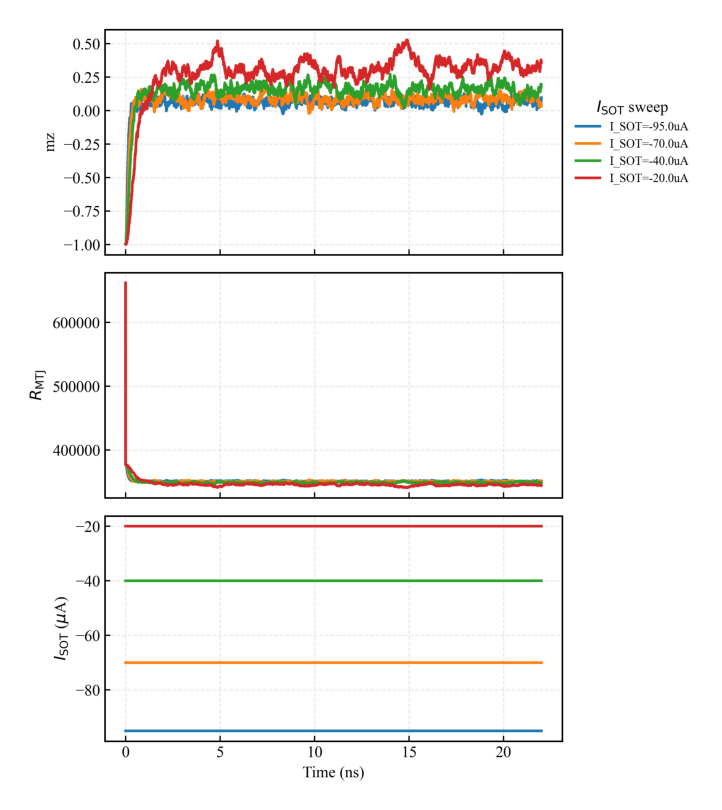

In [23]:
vcma_isot_path = OUT_DIR / "vcma_isot_sweep.png"

save_three_panel_plot(
    vcma_isot_path,
    res.time_s,
    res.mz_curves,
    res.r_mtj_curves,
    res.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=res.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title=r"$I_{\mathrm{SOT}}$ sweep",
    x_is_time=True,
)

print("Saved:", vcma_isot_path)
plt.figure(figsize=(8, 5))
img = plt.imread(vcma_isot_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 6. Example: optimized two-pulse VGSOT using a high-level Config

This is the preferred interface for users who want the optimized VGSOT study but **do not** want to manually manage all low-level pulse arguments.

In [24]:
cfg = OptimizedVgsotSwitchingConfig()
print("Default optimized config:")
pprint(config_to_params(cfg))

Default optimized config:
{'i_sot': None,
 'non': 1,
 'pap': 1,
 'r_sot_fl_dl': 0.0,
 'sim_total_time_s': 2.5e-08,
 't_pairs_s': ((2.5e-08, 0.0),
               (1.4e-09, 1.6e-09),
               (1.8e-09, 1.2e-09),
               (2.2e-09, 8e-10)),
 'tick_spacing_s': 5e-09,
 'v_mtj_1': 1.4937,
 'v_mtj_2': -1.0,
 'vnv': 1}


In [25]:
cfg = OptimizedVgsotSwitchingConfig(
    v_mtj_1=1.45,
    v_mtj_2=-0.9,
    t_pairs_s=[
        (1.2e-9, 1.8e-9),
        (1.5e-9, 1.5e-9),
        (1.8e-9, 1.2e-9),
    ],
    sim_total_time_s=20e-9,
)

res = optimized_vgsot_switching(cfg)
print("Sweep labels:")
for k in res.mz_curves.keys():
    print(" ", k)

direct_excitation: 100%|██████████████████████████████████████████████████████| 20000/20000 [00:00<00:00, 33609.69it/s]

Sweep labels:
  t1=1.20ns,t2=1.80ns
  t1=1.50ns,t2=1.50ns
  t1=1.80ns,t2=1.20ns


## 7. Example: SER simulation and how to customize reliability settings

This example highlights a very important documentation point:

- `trials` controls Monte Carlo sample count
- `target_mz` and `failure_tol` define the failure criterion
- `i_sot_list` defines the x-axis sweep

In [26]:
cfg = SerSotNoVcmaThermalConfig(
    i_sot_list=[-100e-6, -97e-6, -94e-6, -91e-6],
    trials=100,
    failure_tol=1e-1,
)

print("SER config:")
pprint(config_to_params(cfg))

res = ser_sot_no_vcma_thermal(cfg)
print("x:", res.x)
print("SER:", res.ser)

SER config:
{'failure_tol': 0.1,
 'i_sot_list': [-0.0001, -9.7e-05, -9.4e-05, -9.1e-05],
 'non': 1,
 'pap': 1,
 'r_sot_fl_dl': 0.0,
 'sim_end_step': 5000,
 'sim_mid1_step': 2000,
 'sim_start_step': 1,
 'target_mz': -1.0,
 'trials': 100,
 'v_mtj': 0.0,
 'vnv': 0}


MC isot=-9.100e-05A: 100%|███████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.78it/s]

x: [-1.0e-04 -9.7e-05 -9.4e-05 -9.1e-05]
SER: [0.82 0.78 0.67 0.34]


Saved: result_notebook\ser_sot_no_vcma_thermal.png


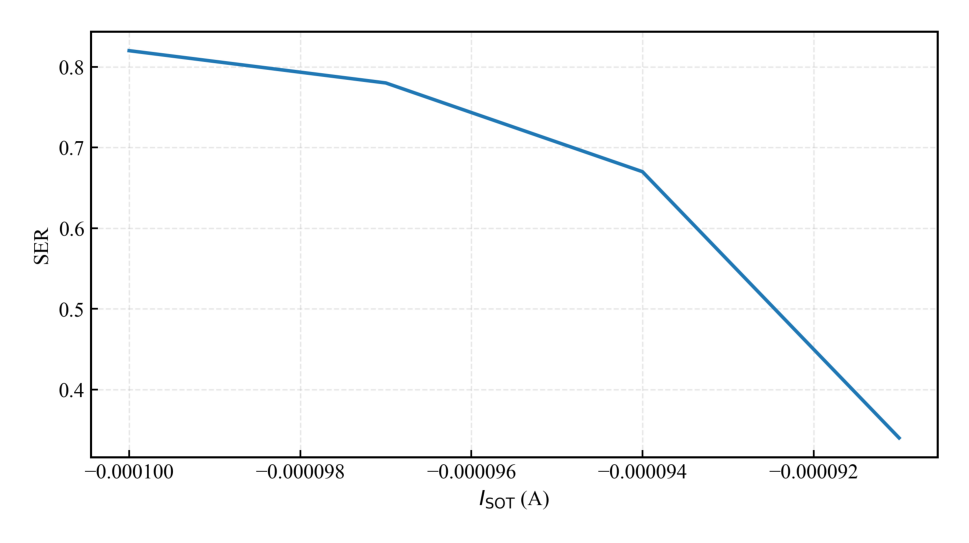

In [27]:
ser_path = OUT_DIR / "ser_sot_no_vcma_thermal.png"

save_single_plot(
    ser_path,
    res.x,
    {"SER": res.ser},
    xlabel=res.x_label,
    ylabel="SER",
    x_is_time=False,
)

print("Saved:", ser_path)
plt.figure(figsize=(6, 4))
img = plt.imread(ser_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 8. Low-level API example: full manual pulse definition

Use a low-level API only when you need direct control over stage-by-stage excitation.

This is the correct place to specify raw values such as:

- pulse timing,
- stage voltages/currents,
- STT/SOT enable flags,
- thermal noise and VCMA switches.

In [28]:
res = run_piecewise_direct_excitation(
    sim_start_step=1,
    sim_mid1_step=1500,
    sim_mid2_step=3000,
    sim_end_step=5000,
    pap=1,

    v_mtj_stage1=1.2,
    v_mtj_stage2=-0.8,
    v_mtj_stage3=0.0,

    i_sot_stage1=-90e-6,
    i_sot_stage2=0.0,
    i_sot_stage3=0.0,

    estt_stage1=0,
    esot_stage1=1,
    estt_stage2=0,
    esot_stage2=1,
    estt_stage3=0,
    esot_stage3=1,

    vnv=1,
    non=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print("time shape:", res.time_s.shape)

direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 34772.35it/s]

SimResult
time shape: (5001,)


## 9. Low-level API example: two-pulse optimized interface

If you need direct control over `t1`, `t2`, and both pulses, use `run_two_pulse_optimized(...)`.

Unlike the high-level case API, this function expects you to explicitly provide the pulse parameters.

In [29]:
res = run_two_pulse_optimized(
    t1_s=1.5e-9,
    t2_s=1.5e-9,
    v_mtj_1=1.4937,
    v_mtj_2=-1.0,
    i_sot_1=-100e-6,
    i_sot_2=0.0,
    sim_total_time_s=25e-9,
    pap=1,
    non=1,
    vnv=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print("time shape:", res.time_s.shape)
print("energy (fJ):", res.switch_energy_j * 1e15)

direct_excitation: 100%|██████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 34493.99it/s]

SimResult
time shape: (25001,)
energy (fJ): 30.66330163258095


## 10. Quick reference: how should users choose an API?

### Choose a high-level case API when:
- you want to reproduce a built-in experiment,
- you want sensible defaults,
- you want to customize only a few knobs.

### Choose a low-level API when:
- you need exact pulse-by-pulse control,
- you want to define stages manually,
- you are building a new experiment not covered by existing case wrappers.

## 11. Quick reference: common documentation patterns you should keep

When adding or updating docs for any new case, always include these four blocks:

1. **Default config**  
   Show `print(cfg)` or `pprint(config_to_params(cfg))`

2. **Minimal runnable example**  
   Show the default call

3. **Custom config example**  
   Override 2–4 representative fields

4. **When to use this API**  
   Explain whether it is a high-level case API or a low-level kernel

## 12. Summary

The most important thing for users to understand is:

- **Config classes are the main parameter interface**
- **Default values are defined in `configs.py`**
- **Use `config_to_params(cfg)` to expose defaults clearly**
- **Customize configs by overriding only selected fields**
- **Drop down to low-level APIs only when you need full manual control**